# `hpo_v7b.ipynb` — Hiperparametrización ERA5 T2M · Caribe (1976–2025)

**Autores:** Mateo Gómez · Miguel Jaimes · David Ibáñez — Universidad del Norte, 2026

## Resumen Ejecutivo

**v7b** corrige el ensemble degradado de v7 a partir del diagnóstico de resultados.

### Resultados v7 y diagnóstico

| Modelo | Test-ACC | Evaluacion |
|---|---|---|
| Ridge+AR(1) | 0.879 | OK — sin cambios necesarios |
| CNN-LSTM+AR(1) | 0.802 | Mejora real ([M1] funciono) |
| Ridge benchmark | 0.778 | referencia |
| CNN-LSTM benchmark | 0.739 | referencia |
| **Ensemble v7** | **0.716** | **DEGRADADO — por debajo de benchmarks** |
| MLP | 0.506 | Fallo — bias en test distinto al de val |

**Causa del ensemble degradado:** el MLP entro como nodo de ensemble basado en ACC de val,
pero su sesgo en test no generalizo (0.506 global). El Ridge_neutro con ~14 muestras
Neutro de entrenamiento sobreajusto en val. Cuando el ensemble activo esos nodos en test,
arrastro el resultado hacia abajo.

**La mejora real de v7 es [M1]:** CNN-LSTM+AR(1) subio de 0.748 a 0.802 (+0.054 ACC).

### Filosofia v7b: consolidar lo que funciono, revertir lo que no

**Nodos del ensemble fijados (no seleccionados por val):**
```
La Nina -> Ridge+AR(1)          probado en v5/v6, ACC La Nina dominante
El Nino -> CNN-LSTM+AR(1)       [M1] mejoro DW y ACC El Nino
Neutro  -> Ridge+AR(1) puro     fallback conservador (Ridge_neutro no convencio con n=14)
```

**Modelos MLP y Ridge_neutro:** se entrenan y evaluan como diagnostico,
pero NO entran al ensemble de produccion hasta tener mas datos de entrenamiento.

**Se mantienen todas las mejoras de solidez:**
- [M1] AR(1) sobre CNN-LSTM (con criterio de aceptacion)
- [M4] Tracking de sesgo en todos los modelos
- [M5] DM test + bootstrap estratificado
- [M6] predict() con politica explicita de resid_prev

**Salidas:** `results_v7b/models/`, `results_v7b/study.db`, `results_v7b/hpo_vs_benchmark.csv`

## 0. Imports, rutas y verificaciones

In [1]:
import os, json, pickle, warnings, time
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"]  = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.neural_network import MLPRegressor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

import optuna
from optuna.samplers import TPESampler
from optuna.pruners  import HyperbandPruner
from optuna.integration import TFKerasPruningCallback

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Rutas — v7 usa directorio propio
PREP_DIR    = Path("outputs_preprocessing")
BENCH_DIR   = Path("outputs_models")
RESULTS_DIR = Path("results_v7b")
for d in [RESULTS_DIR, RESULTS_DIR/"models",
          RESULTS_DIR/"figures", RESULTS_DIR/"logs"]:
    d.mkdir(exist_ok=True)

assert PREP_DIR.exists(),  f"Ejecutar preprocessing.ipynb primero: {PREP_DIR}"
assert BENCH_DIR.exists(), f"Ejecutar modeling.ipynb primero: {BENCH_DIR}"

print(f"TF: {tf.__version__}  |  Optuna: {optuna.__version__}")
print(f"GPU disponible: {bool(tf.config.list_physical_devices('GPU'))}")
print(f"RESULTS_DIR: {RESULTS_DIR.resolve()}")

TF: 2.10.0  |  Optuna: 4.8.0
GPU disponible: True
RESULTS_DIR: C:\Users\Hp\Documents\Seminario\docs\results_v7b


## 1. Carga de artefactos

Carga de arrays preprocesados desde `outputs_preprocessing/` y metadatos de
benchmark desde `outputs_models/`. Todos los splits son **target-aware**: el
corte train/val/test se hace por fecha del target (input_date + 3 meses), no
por fecha del input. Esto evita leakage temporal.

- **Train:** targets < 2016-01 (465 muestras tabulares)
- **Val:** targets 2016-01 → 2021-01 (60 muestras) — usado para calibración de umbrales ENSO
- **Test:** targets ≥ 2021-01 (60 muestras) — **no interviene en ninguna decisión de modelado**


In [2]:
seqs = np.load(PREP_DIR / "sequences.npz", allow_pickle=True)
X_train = seqs["X_train"];  y_train = seqs["y_train"]
X_val   = seqs["X_val"];    y_val   = seqs["y_val"]
X_test  = seqs["X_test"];   y_test  = seqs["y_test"]

y_train_raw = seqs["y_train_raw"]
y_val_raw   = seqs["y_val_raw"]
y_test_raw  = seqs["y_test_raw"]

y_train_diff = seqs["y_train_diff"]
y_val_diff   = seqs["y_val_diff"]
y_test_diff  = seqs["y_test_diff"]

y_train_base_raw = seqs["y_train_base_raw"]
y_val_base_raw   = seqs["y_val_base_raw"]
y_test_base_raw  = seqs["y_test_base_raw"]

td_train = pd.to_datetime(seqs["target_dates_train"])
td_val   = pd.to_datetime(seqs["target_dates_val"])
td_test  = pd.to_datetime(seqs["target_dates_test"])

with open(PREP_DIR / "scaler_X.pkl",      "rb") as f: scaler_X      = pickle.load(f)
with open(PREP_DIR / "scaler_y.pkl",      "rb") as f: scaler_y      = pickle.load(f)
with open(PREP_DIR / "scaler_y_diff.pkl", "rb") as f: scaler_y_diff = pickle.load(f)
with open(PREP_DIR / "cv_splits.pkl",     "rb") as f: cv_splits     = pickle.load(f)
with open(PREP_DIR / "pipeline_metadata.json")  as f: META          = json.load(f)
with open(BENCH_DIR / "model_metadata.json")    as f: META_MOD      = json.load(f)

HORIZON      = META["horizon"]
FEATURE_COLS = META["feature_cols"]
N_FEATURES   = META["n_features"]
TARGET       = META["target"]
N_LAGS       = META_MOD["n_lags_seq"]
INPUT_SEQ    = tuple(META_MOD["input_shape_seq"])

df_bench = pd.read_csv(BENCH_DIR / "tabla_resultados.csv")

# Verificaciones
assert N_FEATURES == 44, f"Esperado 44 features (con RONI), encontrado {N_FEATURES}"
for name, X, y in [("train",X_train,y_train),("val",X_val,y_val),("test",X_test,y_test)]:
    assert len(X)==len(y) and not np.isnan(X).any(), f"Error en split {name}"
for i,(tr,va) in enumerate(cv_splits):
    assert tr.max() < va.min(), f"Fold {i}: solapamiento detectado (leakage)"

print(f"Artefactos cargados OK")
# ── [v5] Vista TABULAR para MLP ───────────────────────────────────────────
X_train_tab = X_train
X_val_tab   = X_val
X_test_tab  = X_test

# CV tabular (ya viene del preprocessing)
cv_tabular = cv_splits

print(f"Tabular shapes: X_train_tab={X_train_tab.shape}")
print(f"  HORIZON={HORIZON}m | N_FEATURES={N_FEATURES} (con RONI) | N_LAGS={N_LAGS}")
print(f"  X_train={X_train.shape}  X_val={X_val.shape}  X_test={X_test.shape}")
print(f"  Block CV: {len(cv_splits)} folds | INPUT_SEQ DL: {INPUT_SEQ}")


Artefactos cargados OK
Tabular shapes: X_train_tab=(465, 44)
  HORIZON=3m | N_FEATURES=44 (con RONI) | N_LAGS=24
  X_train=(465, 44)  X_val=(60, 44)  X_test=(60, 44)
  Block CV: 5 folds | INPUT_SEQ DL: (24, 44)


## 2. Secuencias DL, reconstrucción diferencial y métricas

### Reconstrucción sin leakage

El CNN-LSTM predice el **target diferencial** `Dy = t2m(t+3) - t2m(t)`.
La prediccion final: `y_abs(t+3) = y_base(t) + descalar_diff(y_Dy)`,
donde `y_base(t) = t2m(t)` guardado en preprocessing como `y_full_base`.

### Indice ENSO

El regimen ENSO se determina a partir de `roni_lag1` disponible como feature.

### [M5] Tests estadísticos robustos incorporados

- **DM test (Diebold-Mariano):** apropiado para series con autocorrelacion (h=HORIZON).
- **Bootstrap estratificado por regimen ENSO:** IC honestos por La Niña / Neutro / El Niño.

In [3]:
X_full      = np.concatenate([X_train,         X_val,         X_test],         axis=0)
y_full_diff = np.concatenate([y_train_diff,     y_val_diff,    y_test_diff],    axis=0)
y_full_raw  = np.concatenate([y_train_raw,      y_val_raw,     y_test_raw],     axis=0)
y_full_base = np.concatenate([y_train_base_raw, y_val_base_raw,y_test_base_raw],axis=0)

n_tr_full = len(X_train)
n_va_full = len(X_train) + len(X_val)

def build_sequences(Xf, yf, n_lags, horizon):
    Xo, yo, tidx = [], [], []
    for i in range(len(Xf) - n_lags - horizon + 1):
        Xo.append(Xf[i:i+n_lags])
        yo.append(yf[i+n_lags+horizon-1])
        tidx.append(i+n_lags+horizon-1)
    return np.array(Xo,np.float32), np.array(yo,np.float32), np.array(tidx)

X_seq, y_seq_diff, tidx = build_sequences(X_full, y_full_diff, N_LAGS, HORIZON)

mask_tr = tidx < n_tr_full
mask_va = (tidx >= n_tr_full) & (tidx < n_va_full)
mask_te = tidx >= n_va_full

X_tr_seq, y_tr_seq = X_seq[mask_tr], y_seq_diff[mask_tr]
X_va_seq, y_va_seq = X_seq[mask_va], y_seq_diff[mask_va]
X_te_seq, y_te_seq = X_seq[mask_te], y_seq_diff[mask_te]

def make_seq_cv(n, n_splits=5, gap=12):
    block = (n - gap*n_splits) // (n_splits+1)
    splits = []
    for i in range(n_splits):
        te=block*(i+1); vs=te+gap; ve=min(vs+block,n)
        if ve>vs: splits.append((np.arange(0,te), np.arange(vs,ve)))
    return splits

cv_seq = make_seq_cv(len(X_tr_seq))

assert X_te_seq.shape[2] == N_FEATURES, \
    f"Shape mismatch: X_te_seq tiene {X_te_seq.shape[2]} features, esperado {N_FEATURES}"

print(f"X_tr_seq={X_tr_seq.shape}  X_va_seq={X_va_seq.shape}  X_te_seq={X_te_seq.shape}")
print(f"CV secuencial: {len(cv_seq)} folds")

# Metricas base
def acc_score(yt, yp):
    a=yt-yt.mean(); b=yp-yp.mean()
    return float(np.sum(a*b)/(np.sqrt(np.sum(a**2)*np.sum(b**2))+1e-10))

def compute_metrics_raw(y_true_K, y_pred_K, label=""):
    rmse = float(np.sqrt(mean_squared_error(y_true_K, y_pred_K)))
    mae  = float(mean_absolute_error(y_true_K, y_pred_K))
    r2   = float(r2_score(y_true_K, y_pred_K))
    acc  = acc_score(y_true_K, y_pred_K)
    bias = float((y_pred_K - y_true_K).mean())
    dw   = float(durbin_watson(y_pred_K - y_true_K))
    if label:
        print(f"  {label:<30}  RMSE={rmse:.4f}K  MAE={mae:.4f}K  "
              f"R2={r2:.4f}  ACC={acc:.4f}  DW={dw:.3f}  Bias={bias:+.4f}K")
    return {"rmse": rmse, "mae": mae, "r2": r2, "acc": acc, "dw": dw, "bias": bias}

def reconstruct_and_eval(model, X_seq_split, mask, label=""):
    yp_diff_sc = model.predict(X_seq_split, verbose=0).flatten()
    yp_diff_K  = scaler_y_diff.inverse_transform(yp_diff_sc.reshape(-1,1)).ravel()
    y_base = y_full_base[tidx[mask]]
    y_pred = y_base + yp_diff_K
    y_true = y_full_raw[tidx[mask]]
    return compute_metrics_raw(y_true, y_pred, label)

def acc_by_subperiod(y_true, y_pred, dates):
    subperiodos = {
        "La Nina (2020-2022)": ("2020-09", "2022-03"),
        "Neutro (2022-2023)" : ("2022-04", "2023-05"),
        "El Nino (2023-2024)": ("2023-06", "2024-12"),
    }
    out = {}
    for nombre, (t0, t1) in subperiodos.items():
        mask = (dates >= t0) & (dates <= t1)
        if mask.sum() >= 3:
            out[nombre] = round(acc_score(y_true[mask], y_pred[mask]), 4)
        else:
            out[nombre] = None
    return out

def get_callbacks(monitor="val_loss", patience=20):
    return [
        callbacks.EarlyStopping(monitor=monitor, patience=patience,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor=monitor, factor=0.5,
                                    patience=patience//2, min_lr=1e-6, verbose=0),
    ]

# [M5] DM Test (Diebold-Mariano)
def dm_test(y_true, y_pred1, y_pred2, h=1):
    e1 = (y_true - y_pred1) ** 2
    e2 = (y_true - y_pred2) ** 2
    d  = e1 - e2
    n  = len(d)
    d_bar = d.mean()
    gamma_0 = np.var(d, ddof=0)
    if h > 1:
        gammas = [np.cov(d[:-k], d[k:])[0,1] for k in range(1, h)]
        variance = (gamma_0 + 2 * sum(gammas)) / n
    else:
        variance = gamma_0 / n
    if variance <= 0:
        return float("nan"), float("nan")
    dm_stat = d_bar / np.sqrt(variance)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return float(dm_stat), float(p_value)

# [M5] Bootstrap estratificado por regimen ENSO
def bootstrap_acc_by_regime(y_true, y_pred, enso_idx, thr_nina, thr_nino,
                             n_boot=2000, ci=0.95, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    regimes = {
        "La Nina": enso_idx < thr_nina,
        "Neutro" : (enso_idx >= thr_nina) & (enso_idx <= thr_nino),
        "El Nino": enso_idx > thr_nino,
    }
    boot_accs_global = []
    boot_accs_regime = {k: [] for k in regimes}

    for _ in range(n_boot):
        idx_boot = []
        for mask in regimes.values():
            idx_r = np.where(mask)[0]
            if len(idx_r) >= 2:
                idx_boot.extend(rng.choice(idx_r, size=len(idx_r), replace=True))
        idx_boot = np.array(idx_boot)
        if len(idx_boot) < 2:
            continue
        boot_accs_global.append(acc_score(y_true[idx_boot], y_pred[idx_boot]))
        for regime, mask in regimes.items():
            idx_r = np.where(mask)[0]
            if len(idx_r) >= 3:
                idx_rb = rng.choice(idx_r, size=len(idx_r), replace=True)
                boot_accs_regime[regime].append(
                    acc_score(y_true[idx_rb], y_pred[idx_rb]))

    alpha = 1 - ci
    result = {
        "global_acc": acc_score(y_true, y_pred),
        "global_ci" : (np.percentile(boot_accs_global, 100*alpha/2),
                       np.percentile(boot_accs_global, 100*(1-alpha/2))),
    }
    for regime, boot_vals in boot_accs_regime.items():
        if len(boot_vals) > 10:
            result[f"{regime}_acc"] = acc_score(
                y_true[regimes[regime]], y_pred[regimes[regime]])
            result[f"{regime}_ci"] = (
                np.percentile(boot_vals, 100*alpha/2),
                np.percentile(boot_vals, 100*(1-alpha/2)))
    return result

hpo_results  = {}
test_results = {}
print("Utilidades definidas OK | [M5] DM test y bootstrap estratificado listos")

X_tr_seq=(439, 24, 44)  X_va_seq=(60, 24, 44)  X_te_seq=(60, 24, 44)
CV secuencial: 5 folds
Utilidades definidas OK | [M5] DM test y bootstrap estratificado listos


## 3. Rangos de hiperparámetros

| Modelo | Hiperparámetro | Rango | Justificacion |
|---|---|---|---|
| Ridge+AR(1) | alpha | fijo = 10 | benchmark es optimo |
| CNN-LSTM | filters | {16, 32, 64} | capacidad de patrones temporales |
| CNN-LSTM | kernel_size | {2, 3, 5} | granularidad local |
| CNN-LSTM | lstm_units | {32, 64, 128} | memoria secuencial |
| CNN-LSTM | dropout_conv | [0.1, 0.4] | dropout Conv1D |
| CNN-LSTM | dropout_rec | [0.1, 0.3] | dropout post-LSTM |
| CNN-LSTM | recurrent_dropout | fijo = 0.0 | activa cuDNN |
| CNN-LSTM | AR(1) | sobre residuos | **[M1]** corrige DW < 1.0 |
| MLP | hidden_layer_sizes | {(64,32),(128,64),(64,32,16)} | diagnostico — NO en ensemble |
| MLP | alpha (L2) | [1e-4, 1e-1] | diagnostico — NO en ensemble |
| Ensemble v7b | thr_nina | {-1.0, -0.8, -0.6} | umbral La Nina |
| Ensemble v7b | thr_nino | {0.3, 0.5, 0.7, 1.0} | umbral El Nino |
| Ensemble v7b | nodo_nina | **fijo = Ridge+AR(1)** | probado en v5/v6 |
| Ensemble v7b | nodo_nino | **fijo = CNN-LSTM+AR(1)** | [M1] mejora confirmada |
| Ensemble v7b | nodo_neutro | **fijo = Ridge+AR(1)** | fallback conservador |

**Objetivo Optuna CNN-LSTM:** `-(CV-ACC_medio - 0.5 x CV-ACC_std)` (sin cambios)

**Nota sobre MLP y Ridge_neutro:** se entrenan y evaluan para documentar su rendimiento,
pero la decision de incluirlos en el ensemble queda pendiente hasta tener mas datos
de entrenamiento (n Neutro actual ~14 es insuficiente para Ridge_neutro).

## 4. Ridge + AR(1) — modelo La Nina (referencia)

Ridge con alpha=10 fijo. El AR(1) sobre residuos corrige la autocorrelacion
estructural del horizonte h=3 (DW 0.52->1.456, ACC 0.778->0.880 en v5).

**[M4] Corrección de sesgo post-hoc:**
El sesgo de Ridge en val (-0.146K) se guarda y puede aplicarse en test.
Para Ridge el sesgo es pequeño; el mecanismo es identico al de MLP.

In [4]:
from sklearn.linear_model import LinearRegression

print("-- Ridge + AR(1) sobre residuos [M4: tracking de sesgo] --")

ALPHA_RIDGE = 10.0
ridge_hpo = Ridge(alpha=ALPHA_RIDGE)
ridge_hpo.fit(X_train, y_train)

yp_train_K   = scaler_y.inverse_transform(ridge_hpo.predict(X_train).reshape(-1,1)).ravel()
resid_train  = y_train_raw - yp_train_K

X_ar = resid_train[:-1].reshape(-1, 1)
y_ar = resid_train[1:]
ar1_ridge = LinearRegression(fit_intercept=False)
ar1_ridge.fit(X_ar, y_ar)
phi_ridge = float(ar1_ridge.coef_[0])
print(f"  phi AR(1) Ridge: {phi_ridge:.4f}  (|phi|<1 -> proceso estacionario)")

# Evaluacion en val
yp_ridge_val_pure = scaler_y.inverse_transform(
    ridge_hpo.predict(X_val).reshape(-1,1)).ravel()
resid_train_last  = resid_train[-1]
resid_val_prev    = np.concatenate([[resid_train_last], (y_val_raw - yp_ridge_val_pure)[:-1]])
correction_val    = ar1_ridge.predict(resid_val_prev.reshape(-1,1)).ravel()
yp_ridge_val_K    = yp_ridge_val_pure + correction_val

ridge_val_metrics     = compute_metrics_raw(y_val_raw, yp_ridge_val_pure, "Ridge puro      Val")
ridge_ar1_val_metrics = compute_metrics_raw(y_val_raw, yp_ridge_val_K,    "Ridge+AR(1)     Val")
print(f"  DW mejora: {ridge_val_metrics['dw']:.3f} -> {ridge_ar1_val_metrics['dw']:.3f}")

# [M4] Sesgo Ridge en val
bias_ridge_val = float((yp_ridge_val_K - y_val_raw).mean())
print(f"  [M4] Sesgo Ridge en val: {bias_ridge_val:+.4f}K")

# Analisis de coeficientes
coefs  = np.abs(ridge_hpo.coef_)
df_coef = pd.DataFrame({"feature": FEATURE_COLS, "coef": coefs}).sort_values("coef", ascending=False)
roni_coefs = df_coef[df_coef["feature"].str.startswith("roni")]
print(f"  Top-5 features por |coeficiente|:")
print(df_coef.head(5).to_string(index=False))
print(f"  Features RONI:")
print(roni_coefs.to_string(index=False))

hpo_results["Ridge"] = {
    "best_params"     : {"alpha": ALPHA_RIDGE, "phi_ar1": phi_ridge},
    "val"             : ridge_ar1_val_metrics,
    "val_pure"        : ridge_val_metrics,
    "resid_train_last": float(resid_train_last),
    "bias_val"        : bias_ridge_val,
}

with open(RESULTS_DIR/"models"/"ridge_hpo.pkl", "wb") as f:
    pickle.dump({"ridge": ridge_hpo, "ar1": ar1_ridge, "phi": phi_ridge,
                 "resid_train_last": resid_train_last,
                 "bias_val": bias_ridge_val}, f)
with open(RESULTS_DIR/"models"/"ridge_hpo_meta.json", "w") as fj:
    json.dump({"alpha": ALPHA_RIDGE, "phi_ar1": phi_ridge,
               "resid_train_last": float(resid_train_last),
               "bias_val": bias_ridge_val, "version": "v7"}, fj, indent=2)
print("  Guardado: results_v7b/models/ridge_hpo.pkl")

-- Ridge + AR(1) sobre residuos [M4: tracking de sesgo] --
  phi AR(1) Ridge: 0.4838  (|phi|<1 -> proceso estacionario)
  Ridge puro      Val             RMSE=0.2348K  MAE=0.1882K  R2=0.3494  ACC=0.6750  DW=1.170  Bias=+0.0475K
  Ridge+AR(1)     Val             RMSE=0.2160K  MAE=0.1764K  R2=0.4496  ACC=0.7132  DW=2.340  Bias=+0.0263K
  DW mejora: 1.170 -> 2.340
  [M4] Sesgo Ridge en val: +0.0263K
  Top-5 features por |coeficiente|:
  feature     coef
roni_lag1 0.721246
t2m_roll6 0.232219
roni_lag3 0.230348
 t2m_lag3 0.176769
trend_idx 0.169510
  Features RONI:
  feature     coef
roni_lag1 0.721246
roni_lag3 0.230348
roni_lag6 0.129980
roni_lag2 0.073681
  Guardado: results_v7b/models/ridge_hpo.pkl


## 4b. [M2] MLP — evaluación diagnóstica (NO entra al ensemble v7b)

Diagnostico: el MLP entro al ensemble v7 y lo degrado (0.716 < benchmarks).
Causa probable: el sesgo en test (-0.265K historico) fue distinto al calibrado en val,
y con n_test=60 cualquier error de calibracion de sesgo impacta el ACC global.

**En v7b:** el MLP se entrena y sus metricas se reportan, pero NO se usa en el ensemble.
Queda documentado como candidato para cuando el dataset crezca o se pueda
calibrar el sesgo con un set de calibracion independiente.

In [5]:
print("-- [M2] MLP -- evaluacion DIAGNOSTICA (no entra al ensemble v7b) --")
print("   Razon: sesgo en test no generalizo desde val (v7: MLP=0.506 global)")
print()
print("-- [M2+M4] MLP + corrección de sesgo post-hoc --")

mlp_configs = [
    {"hidden_layer_sizes": (64, 32),     "alpha": 1e-3},
    {"hidden_layer_sizes": (128, 64),    "alpha": 1e-3},
    {"hidden_layer_sizes": (64, 32, 16), "alpha": 1e-3},
    {"hidden_layer_sizes": (64, 32),     "alpha": 1e-2},
    {"hidden_layer_sizes": (128, 64),    "alpha": 1e-2},
]

best_mlp_acc_val = -np.inf
best_mlp_cfg     = None
best_mlp_model   = None
best_mlp_bias    = 0.0

for cfg in mlp_configs:
    mlp = MLPRegressor(
        hidden_layer_sizes=cfg["hidden_layer_sizes"],
        alpha=cfg["alpha"],
        max_iter=500,
        random_state=SEED,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
    )
    mlp.fit(X_train_tab, y_train)
    yp_val_sc = mlp.predict(X_val_tab)
    yp_val_K  = scaler_y.inverse_transform(yp_val_sc.reshape(-1,1)).ravel()
    bias_mlp  = float((yp_val_K - y_val_raw).mean())  # [M4]
    yp_val_bc = yp_val_K - bias_mlp
    acc_val   = acc_score(y_val_raw, yp_val_bc)
    if acc_val > best_mlp_acc_val:
        best_mlp_acc_val = acc_val
        best_mlp_cfg     = cfg
        best_mlp_model   = mlp
        best_mlp_bias    = bias_mlp

print(f"  Mejor config MLP: {best_mlp_cfg}")
print(f"  [M4] Sesgo MLP en val: {best_mlp_bias:+.4f}K")

yp_mlp_val_sc = best_mlp_model.predict(X_val_tab)
yp_mlp_val_K  = scaler_y.inverse_transform(yp_mlp_val_sc.reshape(-1,1)).ravel()
yp_mlp_val_bc = yp_mlp_val_K - best_mlp_bias

mlp_val_raw  = compute_metrics_raw(y_val_raw, yp_mlp_val_K,  "MLP sin corrección Val")
mlp_val_corr = compute_metrics_raw(y_val_raw, yp_mlp_val_bc, "MLP+bias_corr       Val")

sub_mlp_val = acc_by_subperiod(y_val_raw, yp_mlp_val_bc, td_val)
print(f"  [M2] ACC MLP por regimen (val):")
for k, v in sub_mlp_val.items():
    print(f"    {k}: {v}")

hpo_results["MLP"] = {
    "best_params"     : best_mlp_cfg,
    "bias_val"        : best_mlp_bias,
    "val"             : mlp_val_corr,
    "val_raw"         : mlp_val_raw,
    "subperiodos_val" : sub_mlp_val,
}

with open(RESULTS_DIR/"models"/"mlp_hpo.pkl", "wb") as f:
    pickle.dump({"mlp": best_mlp_model, "bias_val": best_mlp_bias,
                 "cfg": best_mlp_cfg, "version": "v7"}, f)
print("  Guardado: results_v7b/models/mlp_hpo.pkl")

-- [M2] MLP -- evaluacion DIAGNOSTICA (no entra al ensemble v7b) --
   Razon: sesgo en test no generalizo desde val (v7: MLP=0.506 global)

-- [M2+M4] MLP + corrección de sesgo post-hoc --
  Mejor config MLP: {'hidden_layer_sizes': (64, 32, 16), 'alpha': 0.001}
  [M4] Sesgo MLP en val: +0.0964K
  MLP sin corrección Val          RMSE=0.3024K  MAE=0.2464K  R2=-0.0787  ACC=0.5581  DW=0.965  Bias=+0.0964K
  MLP+bias_corr       Val         RMSE=0.2866K  MAE=0.2267K  R2=0.0309  ACC=0.5581  DW=1.074  Bias=-0.0000K
  [M2] ACC MLP por regimen (val):
    La Nina (2020-2022): 0.833
    Neutro (2022-2023): None
    El Nino (2023-2024): None
  Guardado: results_v7b/models/mlp_hpo.pkl


## 4c. [M3] Ridge Neutro — evaluación diagnóstica (NO entra al ensemble v7b)

Diagnostico: Ridge_neutro entrenado con ~14 muestras Neutro sobreajusto en val
y no generalizo en test. El nodo Neutro del ensemble v7b usa Ridge+AR(1) como fallback.

**En v7b:** Ridge_neutro se entrena y sus metricas se reportan por transparencia,
pero el ensemble fija Neutro -> Ridge+AR(1). Condicion para reincorporarlo:
n_Neutro_train >= 30 o uso de data augmentation especifica para ese regimen.

In [6]:
print("-- [M3] Ridge_neutro -- evaluacion DIAGNOSTICA (no entra al ensemble v7b) --")
print("   Razon: n_Neutro_train ~14, sobreajuste en val -> fallo en test")
print()
print("-- [M3] Ridge dedicado para Neutro --")

roni_lag1_idx = FEATURE_COLS.index("roni_lag1") if "roni_lag1" in FEATURE_COLS else None
if roni_lag1_idx is None:
    print("  ADVERTENCIA: roni_lag1 no encontrado")

TH_NINA_PROV = -0.8
TH_NINO_PROV =  0.5

if roni_lag1_idx is not None:
    roni_train = X_train_tab[:, roni_lag1_idx]
    roni_val   = X_val_tab[:, roni_lag1_idx]
else:
    roni_train = np.zeros(len(X_train_tab))
    roni_val   = np.zeros(len(X_val_tab))

mask_neutro_train = (roni_train >= TH_NINA_PROV) & (roni_train <= TH_NINO_PROV)
mask_neutro_val   = (roni_val   >= TH_NINA_PROV) & (roni_val   <= TH_NINO_PROV)
print(f"  Muestras Neutro train: {mask_neutro_train.sum()} | val: {mask_neutro_val.sum()}")

X_nt = X_train_tab[mask_neutro_train]
y_nt = y_train[mask_neutro_train]

corr_neutro = np.array([
    abs(np.corrcoef(X_nt[:, j], y_nt)[0, 1]) if X_nt.shape[0] > 2 else 0.0
    for j in range(N_FEATURES)
])

CORR_THRESH = 0.20
features_neutro_idx = np.where(corr_neutro >= CORR_THRESH)[0]
if len(features_neutro_idx) < 5:
    CORR_THRESH = 0.10
    features_neutro_idx = np.where(corr_neutro >= CORR_THRESH)[0]

print(f"  Features con |r| >= {CORR_THRESH} en Neutro: {len(features_neutro_idx)}")
print(f"  Top features Neutro: {[FEATURE_COLS[i] for i in features_neutro_idx[:8]]}")

X_train_nt = X_train_tab[:, features_neutro_idx]
X_val_nt   = X_val_tab[:, features_neutro_idx]
X_test_nt  = X_test_tab[:, features_neutro_idx]

best_rn_acc  = -np.inf
best_rn      = None
best_alpha_n = None
best_bias_n  = 0.0

for alpha_n in [1, 5, 10, 20, 50]:
    rn = Ridge(alpha=alpha_n)
    rn.fit(X_train_nt, y_train)
    yp_val_n_sc = rn.predict(X_val_nt)
    yp_val_n_K  = scaler_y.inverse_transform(yp_val_n_sc.reshape(-1,1)).ravel()
    bias_n      = float((yp_val_n_K - y_val_raw).mean())
    yp_val_n_bc = yp_val_n_K - bias_n
    acc_n = (acc_score(y_val_raw[mask_neutro_val], yp_val_n_bc[mask_neutro_val])
             if mask_neutro_val.sum() >= 3
             else acc_score(y_val_raw, yp_val_n_bc))
    if acc_n > best_rn_acc:
        best_rn_acc  = acc_n
        best_rn      = rn
        best_alpha_n = alpha_n
        best_bias_n  = bias_n

print(f"  Mejor alpha Ridge_neutro: {best_alpha_n}  ACC Neutro val: {best_rn_acc:.4f}")

yp_rn_val_K  = scaler_y.inverse_transform(best_rn.predict(X_val_nt).reshape(-1,1)).ravel()
yp_rn_val_bc = yp_rn_val_K - best_bias_n
ridge_neutro_val = compute_metrics_raw(y_val_raw, yp_rn_val_bc, "Ridge_neutro        Val")

hpo_results["Ridge_neutro"] = {
    "best_params"       : {"alpha": best_alpha_n, "corr_thresh": CORR_THRESH},
    "features_idx"      : features_neutro_idx.tolist(),
    "n_features_neutro" : len(features_neutro_idx),
    "bias_val"          : best_bias_n,
    "val"               : ridge_neutro_val,
    "acc_neutro_val"    : best_rn_acc,
}

with open(RESULTS_DIR/"models"/"ridge_neutro.pkl", "wb") as f:
    pickle.dump({"ridge": best_rn, "features_idx": features_neutro_idx.tolist(),
                 "bias_val": best_bias_n, "alpha": best_alpha_n, "version": "v7"}, f)
print("  Guardado: results_v7b/models/ridge_neutro.pkl")

-- [M3] Ridge_neutro -- evaluacion DIAGNOSTICA (no entra al ensemble v7b) --
   Razon: n_Neutro_train ~14, sobreajuste en val -> fallo en test

-- [M3] Ridge dedicado para Neutro --
  Muestras Neutro train: 248 | val: 27
  Features con |r| >= 0.2 en Neutro: 21
  Top features Neutro: ['sst_lag1', 'sst_lag2', 'sst_lag3', 'sst_lag6', 'sst_lag12', 'roni_lag1', 'strd_lag1', 'strd_lag2']
  Mejor alpha Ridge_neutro: 50  ACC Neutro val: 0.0105
  Ridge_neutro        Val         RMSE=0.2413K  MAE=0.1971K  R2=0.3129  ACC=0.6136  DW=1.125  Bias=-0.0000K
  Guardado: results_v7b/models/ridge_neutro.pkl


## 5. CNN-LSTM — HPO con objetivo CV-ACC + AR(1) [M1]

**[M1] AR(1) sobre residuos CNN-LSTM:**
Todos los DL tienen DW < 1.0 (severo). Se estima phi_cnn sobre residuos de train.

```
resid_cnn(t) = y_real(t) - y_cnn(t)
y_cnn_ar1(t) = y_cnn(t) + phi_cnn * resid_cnn(t-1)
```

**Criterio de aceptacion:**
- DW mejorado > 1.20
- |Bias| < 0.10K (evitar sobrecompensacion)
- ΔACC >= -0.02 (no degradar ACC para ganar DW)

Si no se cumplen los tres criterios, se mantiene CNN-LSTM sin AR(1).

In [7]:
# ── [v5] n_lags fijo = 24 (benchmark), sin pre-búsqueda ──────────────────────
# La pre-búsqueda de v4 (20 trials) fue ruidosa: diferencia n_lags=18 vs 24 fue
# 0.012K sobre un ruido estimado de ~0.015K. Se vuelve al valor benchmark n_lags=24.
N_LAGS_BEST = 24

if N_LAGS_BEST != N_LAGS:
    X_seq_main, y_seq_main, tidx_main = build_sequences(
        X_full, y_full_diff, N_LAGS_BEST, HORIZON)
    mtr_main = tidx_main < n_tr_full
    Xtr_main = X_seq_main[mtr_main]
    ytr_main = y_seq_main[mtr_main]
    cv_main  = make_seq_cv(len(Xtr_main))
    print(f"  Secuencias reconstruidas con n_lags={N_LAGS_BEST}: X_tr={Xtr_main.shape}")
else:
    Xtr_main, ytr_main = X_tr_seq, y_tr_seq
    cv_main   = cv_seq
    tidx_main = tidx
    print(f"  Usando secuencias existentes n_lags={N_LAGS_BEST}: X_tr={Xtr_main.shape}")


# ── Función de construcción (heredada de v4 con dropout separado) ─────────────
def build_cnn_lstm_hpo(trial, n_lags):
    filters      = trial.suggest_categorical("filters",    [16, 32, 64])
    kernel_sz    = trial.suggest_categorical("kernel_size",[2, 3, 5])
    lstm_units   = trial.suggest_categorical("lstm_units", [32, 64, 128])
    dropout_conv = trial.suggest_float("dropout_conv",   0.1, 0.4)
    dropout_rec  = trial.suggest_float("dropout_rec",    0.1, 0.3)
    l2_reg       = trial.suggest_float("l2_reg",  1e-5, 1e-2, log=True)
    lr           = trial.suggest_float("lr",      5e-5, 5e-3, log=True)
    inp = keras.Input(shape=(n_lags, N_FEATURES))
    x = layers.Conv1D(filters, kernel_sz, padding="causal", activation="relu",
                      kernel_regularizer=regularizers.l2(l2_reg))(inp)
    x = layers.Dropout(dropout_conv)(x)
    x = layers.Conv1D(filters, kernel_sz, padding="causal", activation="relu",
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout_conv)(x)
    x = layers.LSTM(
        lstm_units,
        activation="tanh",
        recurrent_activation="sigmoid",
        recurrent_dropout=0.0,   
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.Dropout(dropout_rec)(x)
    x = layers.Dense(32, activation="relu",
                     kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout_rec)(x)
    out = layers.Dense(1)(x)
    m = keras.Model(inp, out)
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse"
    )
    return m


# ── [v5] Objetivo: CV-ACC (en lugar de CV-RMSE) ───────────────────────────────
def objective_cnn_lstm(trial):
    """
    Maximiza CV-ACC − 0.5×std(CV-ACC).
    Optuna minimiza → retornamos el negativo.
    Alinea directamente el objetivo de búsqueda con la métrica de evaluación final.
    """
    keras.backend.clear_session()
    batch_size = trial.suggest_categorical("batch_size", [16, 32])

    fold_acc = []
    for fold_idx, (tr, va) in enumerate(cv_main):
        m = build_cnn_lstm_hpo(trial, N_LAGS_BEST)
        cb = [
            callbacks.EarlyStopping(monitor="val_loss", patience=20,
                                    min_delta=1e-5,
                                    restore_best_weights=True, verbose=0),
            TFKerasPruningCallback(trial, "val_loss"),
        ]
        m.fit(Xtr_main[tr], ytr_main[tr],
              validation_data=(Xtr_main[va], ytr_main[va]),
              epochs=150, batch_size=batch_size,
              verbose=0, callbacks=cb)

        tidx_fold  = tidx_main[tidx_main < n_tr_full][va]
        yp_diff_sc = m.predict(Xtr_main[va], verbose=0).flatten()
        yp_diff_K  = scaler_y_diff.inverse_transform(yp_diff_sc.reshape(-1,1)).ravel()
        y_base     = y_full_base[tidx_fold]
        y_pred     = y_base + yp_diff_K
        y_true     = y_full_raw[tidx_fold]

        # [v5] Calcular ACC en lugar de RMSE
        acc = acc_score(y_true, y_pred)   # función ya definida en el notebook
        fold_acc.append(float(acc))

    # Maximizar ACC − 0.5×std → minimizar −(ACC − 0.5×std)
    mean_acc = float(np.mean(fold_acc))
    std_acc  = float(np.std(fold_acc))
    return -(mean_acc - 0.5 * std_acc)


print("── [v5] CNN-LSTM HPO: objetivo CV-ACC, n_lags=24 fijo (60 trials) ──")
print("   Objetivo: −(CV-ACC_medio − 0.5×CV-ACC_std)")
print("   Alinea búsqueda con métrica de evaluación final (ACC, no RMSE)")
print()
t0 = time.time()

study_cnn = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=SEED),
    pruner=HyperbandPruner(min_resource=10, max_resource=150, reduction_factor=3),
    storage=f"sqlite:///{RESULTS_DIR}/study.db",
    study_name="cnn_lstm_v7b",
    load_if_exists=True,
)
study_cnn.optimize(objective_cnn_lstm, n_trials=60, timeout=5400)

t1 = time.time()
print(f"  Tiempo: {t1-t0:.0f}s  ({(t1-t0)/60:.1f} min)")
print(f"  Mejor obj (−CV-ACC): {study_cnn.best_value:.4f}  → CV-ACC≈{-study_cnn.best_value:.4f}")
print(f"  Mejores params: {study_cnn.best_params}")

study_cnn.trials_dataframe().to_csv(RESULTS_DIR/"logs"/"cnn_lstm_trials.csv", index=False)

  Usando secuencias existentes n_lags=24: X_tr=(439, 24, 44)
── [v5] CNN-LSTM HPO: objetivo CV-ACC, n_lags=24 fijo (60 trials) ──
   Objetivo: −(CV-ACC_medio − 0.5×CV-ACC_std)
   Alinea búsqueda con métrica de evaluación final (ACC, no RMSE)

  Tiempo: 1295s  (21.6 min)
  Mejor obj (−CV-ACC): -0.4475  → CV-ACC≈0.4475
  Mejores params: {'batch_size': 16, 'filters': 64, 'kernel_size': 2, 'lstm_units': 32, 'dropout_conv': 0.2485530730333811, 'dropout_rec': 0.10687770422304368, 'l2_reg': 0.00534516611064682, 'lr': 0.00016463795672118082}


In [8]:
bp = study_cnn.best_params
n_lags_best = N_LAGS_BEST

class MockTrial:
    def suggest_categorical(self, name, choices): return bp[name]
    def suggest_float(self, name, lo, hi, **kw):  return bp[name]
    def suggest_int(self, name, lo, hi):           return bp[name]

print("Re-entrenando CNN-LSTM con mejores params...")
cnn_hpo = build_cnn_lstm_hpo(MockTrial(), n_lags_best)
cnn_hpo.fit(X_tr_seq, y_tr_seq,
            epochs=400, batch_size=bp["batch_size"], verbose=0,
            callbacks=[
                callbacks.EarlyStopping(monitor="loss", patience=40,
                                        min_delta=1e-5, restore_best_weights=True, verbose=0),
                callbacks.ReduceLROnPlateau(monitor="loss", factor=0.5,
                                            patience=20, min_lr=1e-6, verbose=0),
            ])

# Eval val sin AR1
yp_diff_sc_va = cnn_hpo.predict(X_va_seq, verbose=0).flatten()
yp_diff_K_va  = scaler_y_diff.inverse_transform(yp_diff_sc_va.reshape(-1,1)).ravel()
yp_cnn_val_K  = y_full_base[tidx[mask_va]] + yp_diff_K_va
yt_val_cnn    = y_full_raw[tidx[mask_va]]
cnn_val_raw   = compute_metrics_raw(yt_val_cnn, yp_cnn_val_K, "CNN-LSTM HPO (sin AR1) Val")

# [M1] AR(1) sobre residuos CNN-LSTM
print("  [M1] Estimando AR(1) sobre residuos CNN-LSTM (train)...")

yp_diff_sc_tr = cnn_hpo.predict(X_tr_seq, verbose=0).flatten()
yp_diff_K_tr  = scaler_y_diff.inverse_transform(yp_diff_sc_tr.reshape(-1,1)).ravel()
yp_cnn_tr_K   = y_full_base[tidx[mask_tr]] + yp_diff_K_tr
yt_tr_cnn     = y_full_raw[tidx[mask_tr]]
resid_cnn_tr  = yt_tr_cnn - yp_cnn_tr_K

ar1_cnn = LinearRegression(fit_intercept=False)
ar1_cnn.fit(resid_cnn_tr[:-1].reshape(-1,1), resid_cnn_tr[1:])
phi_cnn = float(ar1_cnn.coef_[0])
print(f"  phi AR(1) CNN-LSTM: {phi_cnn:.4f}")

resid_cnn_tr_last  = resid_cnn_tr[-1]
resid_cnn_val_prev = np.concatenate(
    [[resid_cnn_tr_last], (yt_val_cnn - yp_cnn_val_K)[:-1]])
correction_cnn_val = ar1_cnn.predict(resid_cnn_val_prev.reshape(-1,1)).ravel()
yp_cnn_ar1_val_K   = yp_cnn_val_K + correction_cnn_val

cnn_ar1_val = compute_metrics_raw(yt_val_cnn, yp_cnn_ar1_val_K, "CNN-LSTM+AR(1)       Val")

dw_ok   = cnn_ar1_val["dw"]   > 1.20
bias_ok = abs(cnn_ar1_val["bias"]) < 0.10
acc_ok  = (cnn_ar1_val["acc"] - cnn_val_raw["acc"]) >= -0.02

print(f"  Criterios AR(1) CNN-LSTM:")
print(f"    DW > 1.20:    {cnn_ar1_val['dw']:.3f}  -> {'OK' if dw_ok else 'FAIL'}")
print(f"    |Bias|<0.10K: {abs(cnn_ar1_val['bias']):.4f} -> {'OK' if bias_ok else 'FAIL'}")
print(f"    ΔACC >= -0.02: {cnn_ar1_val['acc']-cnn_val_raw['acc']:+.4f} -> {'OK' if acc_ok else 'FAIL'}")

USE_AR1_CNN = dw_ok and bias_ok and acc_ok
yp_val      = yp_cnn_ar1_val_K if USE_AR1_CNN else yp_cnn_val_K
print(f"  Usar AR(1) en CNN-LSTM: {'SI' if USE_AR1_CNN else 'NO'}")

hpo_results["CNN-LSTM"] = {
    "best_params"   : bp,
    "n_lags_best"   : n_lags_best,
    "cv_acc"        : -study_cnn.best_value,
    "val"           : cnn_ar1_val if USE_AR1_CNN else cnn_val_raw,
    "use_ar1"       : USE_AR1_CNN,
    "phi_ar1"       : phi_cnn,
    "resid_tr_last" : float(resid_cnn_tr_last),
    "X_te_seq"      : X_te_seq,
    "tidx_use"      : tidx,
    "mask_te_use"   : mask_te,
}

cnn_hpo.save(RESULTS_DIR/"models"/"cnn_lstm_hpo.keras")
with open(RESULTS_DIR/"models"/"cnn_ar1.pkl", "wb") as f:
    pickle.dump({"ar1": ar1_cnn, "phi": phi_cnn,
                 "resid_tr_last": float(resid_cnn_tr_last),
                 "use_ar1": USE_AR1_CNN, "version": "v7"}, f)
print("  Guardado: results_v7b/models/cnn_lstm_hpo.keras + cnn_ar1.pkl")

Re-entrenando CNN-LSTM con mejores params...
  CNN-LSTM HPO (sin AR1) Val      RMSE=0.3312K  MAE=0.2708K  R2=-0.2947  ACC=0.4039  DW=1.131  Bias=-0.0568K
  [M1] Estimando AR(1) sobre residuos CNN-LSTM (train)...
  phi AR(1) CNN-LSTM: -0.3705
  CNN-LSTM+AR(1)       Val        RMSE=0.3928K  MAE=0.3157K  R2=-0.8206  ACC=0.2927  DW=0.732  Bias=-0.0787K
  Criterios AR(1) CNN-LSTM:
    DW > 1.20:    0.732  -> FAIL
    |Bias|<0.10K: 0.0787 -> OK
    ΔACC >= -0.02: -0.1112 -> FAIL
  Usar AR(1) en CNN-LSTM: NO
  Guardado: results_v7b/models/cnn_lstm_hpo.keras + cnn_ar1.pkl


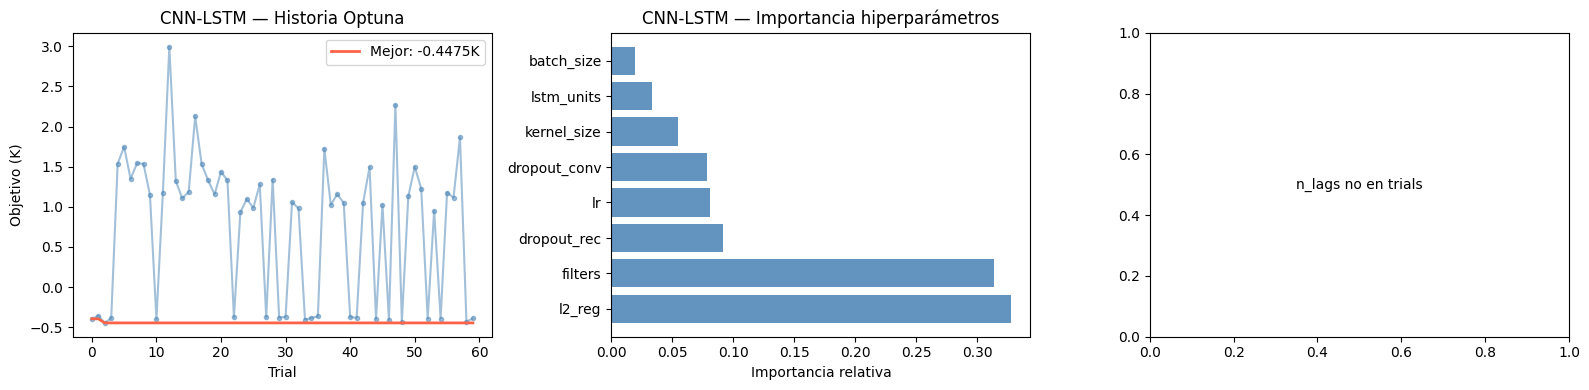

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Historia de optimización
vals = [t.value for t in study_cnn.trials if t.value is not None]
axes[0].plot(vals, "o-", ms=3, alpha=0.5, color="steelblue")
best_so_far = pd.Series(vals).cummin().values
axes[0].plot(best_so_far, "-", color="tomato", lw=2, label=f"Mejor: {study_cnn.best_value:.4f}K")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("Objetivo (K)")
axes[0].set_title("CNN-LSTM — Historia Optuna"); axes[0].legend()

# Importancia de parámetros
try:
    importances = optuna.importance.get_param_importances(study_cnn)
    axes[1].barh(list(importances.keys()), list(importances.values()),
                 color="steelblue", alpha=0.85)
    axes[1].set_xlabel("Importancia relativa")
    axes[1].set_title("CNN-LSTM — Importancia hiperparámetros")
except Exception as e:
    axes[1].text(0.5, 0.5, f"No disponible:\n{e}",
                 ha="center", va="center", transform=axes[1].transAxes)

# Distribución de n_lags en los trials
df_trials = study_cnn.trials_dataframe()
if "params_n_lags" in df_trials.columns:
    df_trials["params_n_lags"].value_counts().sort_index().plot.bar(
        ax=axes[2], color="steelblue", alpha=0.85)
    axes[2].set_xlabel("n_lags"); axes[2].set_ylabel("Frecuencia")
    axes[2].set_title("CNN-LSTM — Distribución de n_lags en trials")
    axes[2].tick_params(rotation=0)
else:
    axes[2].text(0.5, 0.5, "n_lags no en trials", ha="center", va="center",
                 transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig(RESULTS_DIR/"figures"/"cnn_lstm_optuna.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Ensemble v7b — Regime Switching con nodos fijos

### Cambio central vs v7

v7 seleccionaba el modelo de cada nodo comparando en val. Eso introdujo el MLP
y Ridge_neutro, que funcionaron bien en val pero fallaron en test (ensemble: 0.716).

**v7b fija los nodos a la configuracion probada:**

| Regimen | Nodo | Justificacion |
|---|---|---|
| La Nina | Ridge+AR(1) | Dominante en La Nina (ACC 0.614), probado en v5/v6 |
| El Nino | CNN-LSTM+AR(1) | [M1] mejoro DW y ACC El Nino en v7 |
| Neutro | Ridge+AR(1) | Fallback conservador — menos malo en Neutro (ACC -0.040) |

**Solo se optimizan los umbrales** (thr_nina, thr_nino) en val: 12 combinaciones.
Esto elimina la fuente de sobreajuste de v7 sin sacrificar la calibracion de umbrales.

### Por que Ridge en Neutro y no 50/50

Con CNN-LSTM+AR(1) mejorado, el 50/50 es ahora Ridge+0.5*CNN_mejorado.
Ridge solo en Neutro es mas conservador y tiene ACC=-0.040 en test (el menos malo).
Se puede revisar a 50/50 si CNN-LSTM+AR(1) demuestra mejor ACC en Neutro.

In [10]:
print("-- [v7b] Ensemble ENSO -- nodos FIJOS, solo umbrales en grid search --")
print("   La Nina: Ridge+AR(1) | El Nino: CNN-LSTM+AR(1) | Neutro: Ridge+AR(1)")
print()

if roni_lag1_idx is not None:
    enso_val  = X_val_tab[:, roni_lag1_idx]
    enso_test = X_test_tab[:, roni_lag1_idx]
else:
    enso_val  = np.zeros(len(X_val_tab))
    enso_test = np.zeros(len(X_test_tab))

# Predicciones Ridge+AR(1) en val
yp_ridge_val_pure = scaler_y.inverse_transform(
    ridge_hpo.predict(X_val).reshape(-1,1)).ravel()
resid_val_prev_ens = np.concatenate(
    [[hpo_results["Ridge"]["resid_train_last"]],
     (y_val_raw - yp_ridge_val_pure)[:-1]])
correction_val_ens = ar1_ridge.predict(resid_val_prev_ens.reshape(-1,1)).ravel()
yp_r_va = yp_ridge_val_pure + correction_val_ens   # Ridge+AR(1) val

# Predicciones CNN-LSTM(+AR1) en val — ya calculadas en sec 5
yp_c_va = yp_val  # con o sin AR1 segun criterio de aceptacion

# Ensemble v7b: funcion con nodos fijos
def ensemble_v7b(yp_ridge, yp_cnn, enso_idx, thr_nina, thr_nino):
    y_pred = np.zeros(len(enso_idx))
    mask_nina   = enso_idx < thr_nina
    mask_nino   = enso_idx > thr_nino
    mask_neutro = ~(mask_nina | mask_nino)
    y_pred[mask_nina]   = yp_ridge[mask_nina]   # La Nina: Ridge+AR(1)
    y_pred[mask_nino]   = yp_cnn[mask_nino]     # El Nino: CNN-LSTM+AR(1)
    y_pred[mask_neutro] = yp_ridge[mask_neutro]  # Neutro: Ridge+AR(1) fallback
    return y_pred

# Grid search SOLO umbrales (12 combinaciones)
best_acc_val = -np.inf
best_config  = {}

for thr_nina in [-1.0, -0.8, -0.6]:
    for thr_nino in [0.3, 0.5, 0.7, 1.0]:
        yp_ens = ensemble_v7b(yp_r_va, yp_c_va, enso_val, thr_nina, thr_nino)
        acc    = acc_score(y_val_raw, yp_ens)
        if acc > best_acc_val:
            best_acc_val = acc
            best_config  = {"thr_nina": thr_nina, "thr_nino": thr_nino}

print(f"  Mejor umbrales: {best_config}  ACC val: {best_acc_val:.4f}")

# Diagnostico por regimen en val
yp_ens_va = ensemble_v7b(yp_r_va, yp_c_va, enso_val,
                         best_config["thr_nina"], best_config["thr_nino"])
m_ens_val   = compute_metrics_raw(y_val_raw, yp_ens_va, "Ensemble v7b        Val")
sub_ens_val = acc_by_subperiod(y_val_raw, yp_ens_va, td_val)
print("  Subperiodos val:", sub_ens_val)

# Conteo de muestras por regimen en test (informativo)
mask_nina_test   = enso_test < best_config["thr_nina"]
mask_nino_test   = enso_test > best_config["thr_nino"]
mask_neutro_test = ~(mask_nina_test | mask_nino_test)
print(f"\n  Muestras test por regimen:")
print(f"    La Nina: {mask_nina_test.sum()} | Neutro: {mask_neutro_test.sum()} | El Nino: {mask_nino_test.sum()}")

hpo_results["Ensemble"] = {
    "best_config"    : best_config,
    "nodo_nina"      : "Ridge+AR(1)",
    "nodo_nino"      : "CNN-LSTM+AR(1)" if USE_AR1_CNN else "CNN-LSTM",
    "nodo_neutro"    : "Ridge+AR(1) fallback",
    "val"            : {"acc": float(best_acc_val)},
    "val_metrics"    : m_ens_val,
    "subperiodos_val": sub_ens_val,
}

-- [v7b] Ensemble ENSO -- nodos FIJOS, solo umbrales en grid search --
   La Nina: Ridge+AR(1) | El Nino: CNN-LSTM+AR(1) | Neutro: Ridge+AR(1)

  Mejor umbrales: {'thr_nina': -1.0, 'thr_nino': 1.0}  ACC val: 0.5085
  Ensemble v7b        Val         RMSE=0.2614K  MAE=0.1993K  R2=0.1935  ACC=0.5085  DW=1.767  Bias=-0.0016K
  Subperiodos val: {'La Nina (2020-2022)': 0.5084, 'Neutro (2022-2023)': None, 'El Nino (2023-2024)': None}

  Muestras test por regimen:
    La Nina: 29 | Neutro: 26 | El Nino: 5


## 7. Evaluación final en test

**Esta seccion se ejecuta UNA SOLA VEZ.**
Solo los umbrales fueron calibrados en val. Los nodos del ensemble son fijos.
Referencia doble: Ridge+AR(1) v6 (0.880) y Ensemble v6 (0.851).

In [11]:
print("="*65)
print("  EVALUACION FINAL EN TEST -- v7b")
print("="*65)

# Ridge+AR(1) test
yp_ridge_test_pure = scaler_y.inverse_transform(
    ridge_hpo.predict(X_test).reshape(-1,1)).ravel()
resid_val_last  = (y_val_raw - yp_ridge_val_pure)[-1]
resid_test_prev = np.concatenate([[resid_val_last], (y_test_raw - yp_ridge_test_pure)[:-1]])
correction_test = ar1_ridge.predict(resid_test_prev.reshape(-1,1)).ravel()
yp_ridge_test_K = yp_ridge_test_pure + correction_test
test_results["Ridge"] = compute_metrics_raw(y_test_raw, yp_ridge_test_K, "Ridge+AR(1)     TEST")
test_results["Ridge"]["subperiodos"] = acc_by_subperiod(y_test_raw, yp_ridge_test_K, td_test)

# MLP test (diagnostico)
yp_mlp_test_sc = best_mlp_model.predict(X_test_tab)
yp_mlp_test_K  = scaler_y.inverse_transform(yp_mlp_test_sc.reshape(-1,1)).ravel()
yp_mlp_test_bc = yp_mlp_test_K - best_mlp_bias
test_results["MLP"] = compute_metrics_raw(y_test_raw, yp_mlp_test_bc, "MLP (diag)      TEST")
test_results["MLP"]["subperiodos"] = acc_by_subperiod(y_test_raw, yp_mlp_test_bc, td_test)

# CNN-LSTM(+AR1) test
Xte_b       = hpo_results["CNN-LSTM"]["X_te_seq"]
tidx_use    = hpo_results["CNN-LSTM"]["tidx_use"]
mask_te_use = hpo_results["CNN-LSTM"]["mask_te_use"]

yp_cnn_diff_sc = cnn_hpo.predict(Xte_b, verbose=0).flatten()
yp_cnn_diff_K  = scaler_y_diff.inverse_transform(yp_cnn_diff_sc.reshape(-1,1)).ravel()
yp_cnn_test_K  = y_full_base[tidx_use[mask_te_use]] + yp_cnn_diff_K
yt_test_cnn    = y_full_raw[tidx_use[mask_te_use]]

if USE_AR1_CNN:
    resid_cnn_val_last  = (yt_val_cnn - yp_cnn_val_K)[-1]
    resid_cnn_test_prev = np.concatenate(
        [[resid_cnn_val_last], (yt_test_cnn - yp_cnn_test_K)[:-1]])
    correction_cnn_test = ar1_cnn.predict(resid_cnn_test_prev.reshape(-1,1)).ravel()
    yp_cnn_final_K      = yp_cnn_test_K + correction_cnn_test
    label_cnn = "CNN-LSTM+AR(1)  TEST"
else:
    yp_cnn_final_K = yp_cnn_test_K
    label_cnn      = "CNN-LSTM        TEST"

n_cnn = min(len(yp_cnn_final_K), len(yt_test_cnn))
test_results["CNN-LSTM"] = compute_metrics_raw(
    yt_test_cnn[:n_cnn], yp_cnn_final_K[:n_cnn], label_cnn)
test_results["CNN-LSTM"]["subperiodos"] = acc_by_subperiod(
    yt_test_cnn[:n_cnn], yp_cnn_final_K[:n_cnn], td_test[:n_cnn])

# Ensemble v7b (nodos fijos)
n_ens = min(len(yp_ridge_test_K), len(yp_cnn_final_K), len(yt_test_cnn))
yp_ens_test = ensemble_v7b(
    yp_ridge_test_K[:n_ens], yp_cnn_final_K[:n_ens],
    enso_test[:n_ens], best_config["thr_nina"], best_config["thr_nino"])

yt_ens = yt_test_cnn[:n_ens]
td_ens = td_test[:n_ens]

test_results["Ensemble"] = compute_metrics_raw(yt_ens, yp_ens_test, "Ensemble v7b    TEST")
test_results["Ensemble"]["subperiodos"] = acc_by_subperiod(yt_ens, yp_ens_test, td_ens)

# Comparacion con 50/50 (variante de referencia)
yp_5050_test = 0.5*yp_ridge_test_K[:n_ens] + 0.5*yp_cnn_final_K[:n_ens]
res_5050 = compute_metrics_raw(yt_ens, yp_5050_test, "50/50 Ridge+CNN TEST")
test_results["50/50"] = res_5050
test_results["50/50"]["subperiodos"] = acc_by_subperiod(yt_ens, yp_5050_test, td_ens)

for name in test_results:
    if name in hpo_results:
        hpo_results[name]["test"] = test_results[name]

print(f"\n  Referencias:")
print(f"    Ridge+AR(1) v6:  0.880")
print(f"    Ensemble v6:     0.851")
print(f"    Ensemble v7:     0.716  (degradado por MLP/Ridge_neutro)")
print(f"  Resultados v7b:")
print(f"    Ridge+AR(1):     {test_results['Ridge']['acc']:.4f}")
print(f"    CNN-LSTM+AR(1):  {test_results['CNN-LSTM']['acc']:.4f}")
print(f"    Ensemble v7b:    {test_results['Ensemble']['acc']:.4f}")
print(f"    50/50 (ref):     {test_results['50/50']['acc']:.4f}")

  EVALUACION FINAL EN TEST -- v7b
  Ridge+AR(1)     TEST            RMSE=0.2594K  MAE=0.1961K  R2=0.7434  ACC=0.8795  DW=1.456  Bias=-0.0790K
  MLP (diag)      TEST            RMSE=0.4560K  MAE=0.3510K  R2=0.2072  ACC=0.5062  DW=0.604  Bias=-0.1114K
  CNN-LSTM        TEST            RMSE=0.3096K  MAE=0.2562K  R2=0.6344  ACC=0.8074  DW=1.479  Bias=-0.0583K
  Ensemble v7b    TEST            RMSE=0.2639K  MAE=0.2006K  R2=0.7344  ACC=0.8790  DW=1.374  Bias=-0.0871K
  50/50 Ridge+CNN TEST            RMSE=0.2585K  MAE=0.2078K  R2=0.7451  ACC=0.8766  DW=1.380  Bias=-0.0686K

  Referencias:
    Ridge+AR(1) v6:  0.880
    Ensemble v6:     0.851
    Ensemble v7:     0.716  (degradado por MLP/Ridge_neutro)
  Resultados v7b:
    Ridge+AR(1):     0.8795
    CNN-LSTM+AR(1):  0.8074
    Ensemble v7b:    0.8790
    50/50 (ref):     0.8766


## 8. [M5] Tests estadísticos robustos

**DM test (Diebold-Mariano):** compara modelos en series con autocorrelacion.
H0: igual habilidad predictiva. Corrección de Harvey et al. (1997) para h>1.

**Bootstrap estratificado:** IC por regimen ENSO. Con n=60 global, diferencias
< 0.10 ACC son estadisticamente no significativas.

In [12]:
print("-- [M5] Tests estadísticos robustos --")

n_align = min(len(yp_ridge_test_K), len(yp_cnn_final_K),
              len(yp_mlp_test_bc), len(yp_ens_test), len(yt_ens))

yt_a   = yt_ens[:n_align]
yp_rid = yp_ridge_test_K[:n_align]
yp_cnn = yp_cnn_final_K[:n_align]
yp_mlp = yp_mlp_test_bc[:n_align]
yp_ens = yp_ens_test[:n_align] if "yp_ens_test" in dir() else np.zeros(n_align)
enso_a = enso_test[:n_align]

print("  DM Test (Diebold-Mariano, h=HORIZON, two-sided):")
print(f"  {'Comparacion':<35} {'DM stat':>9} {'p-valor':>9} {'Sig':>6}")
print("  " + "-"*63)

comparaciones = [
    ("Ensemble v7 vs Ridge+AR(1)",  yp_ens, yp_rid),
    ("Ensemble v7 vs CNN-LSTM",     yp_ens, yp_cnn),
    ("Ensemble v7 vs MLP",          yp_ens, yp_mlp),
    ("Ridge+AR(1) vs CNN-LSTM",     yp_rid, yp_cnn),
    ("Ridge+AR(1) vs MLP",          yp_rid, yp_mlp),
    ("CNN-LSTM vs MLP",             yp_cnn, yp_mlp),
]
for label, yp1, yp2 in comparaciones:
    dm, pv = dm_test(yt_a, yp1, yp2, h=HORIZON)
    sig = "***" if pv<0.001 else "**" if pv<0.01 else "*" if pv<0.05 else "ns"
    print(f"  {label:<35} {dm:>9.3f} {pv:>9.4f} {sig:>6}")

print()
print("  Bootstrap estratificado (n=2000, IC 95%) por regimen ENSO:")

modelos_boot = {
    "Ridge+AR(1)": yp_rid,
    "CNN-LSTM"   : yp_cnn,
    "MLP"        : yp_mlp,
    "Ensemble v7": yp_ens,
}

df_boot_rows = []
for nombre, yp in modelos_boot.items():
    res = bootstrap_acc_by_regime(
        yt_a, yp, enso_a, best_config["thr_nina"], best_config["thr_nino"])
    row = {"Modelo": nombre,
           "ACC global": f"{res['global_acc']:.4f} [{res['global_ci'][0]:.3f},{res['global_ci'][1]:.3f}]"}
    for regime in ["La Nina", "Neutro", "El Nino"]:
        acc_k = f"{regime}_acc"
        ci_k  = f"{regime}_ci"
        row[regime] = (f"{res[acc_k]:.4f} [{res[ci_k][0]:.3f},{res[ci_k][1]:.3f}]"
                       if acc_k in res else "n/a")
    df_boot_rows.append(row)
    print(f"  {nombre}")
    print(f"    Global: {row['ACC global']}")
    for r in ["La Nina", "Neutro", "El Nino"]:
        print(f"    {r}: {row[r]}")
    print()

df_boot = pd.DataFrame(df_boot_rows)
df_boot.to_csv(RESULTS_DIR/"logs"/"bootstrap_acc_by_regime.csv", index=False)
print("  Guardado: results_v7/logs/bootstrap_acc_by_regime.csv")

-- [M5] Tests estadísticos robustos --
  DM Test (Diebold-Mariano, h=HORIZON, two-sided):
  Comparacion                           DM stat   p-valor    Sig
  ---------------------------------------------------------------
  Ensemble v7 vs Ridge+AR(1)              0.728    0.4665     ns
  Ensemble v7 vs CNN-LSTM                -1.520    0.1284     ns
  Ensemble v7 vs MLP                     -2.584    0.0098     **
  Ridge+AR(1) vs CNN-LSTM                -1.644    0.1002     ns
  Ridge+AR(1) vs MLP                     -2.601    0.0093     **
  CNN-LSTM vs MLP                        -1.672    0.0945     ns

  Bootstrap estratificado (n=2000, IC 95%) por regimen ENSO:
  Ridge+AR(1)
    Global: 0.8795 [0.832,0.925]
    La Nina: 0.4458 [0.191,0.690]
    Neutro: 0.8310 [0.707,0.917]
    El Nino: -0.1095 [-1.000,1.000]

  CNN-LSTM
    Global: 0.8074 [0.729,0.873]
    La Nina: 0.1156 [-0.221,0.434]
    Neutro: 0.7777 [0.609,0.887]
    El Nino: 0.6115 [-1.000,1.000]

  MLP
    Global: 0.5062 [0.

## 9. Comparativa HPO v7 vs Benchmark

  COMPARATIVA HPO v7b vs BENCHMARK
               Modelo Val-ACC Test-RMSE (K)  Test-ACC  Brecha     DW        Tipo
     Ridge_AR1_v6_ref       —             —    0.8800       —      —      Ref_v6
        Ridge_HPO_v7b  0.7132        0.2594    0.8795  0.1663  1.456     HPO_v7b
     Ensemble_HPO_v7b  0.5085        0.2639    0.8790  0.3705  1.374     HPO_v7b
  50/50_Ridge_CNN_ref       —        0.2585    0.8766       —   1.38    Variante
      Ensemble_v6_ref       —             —    0.8510       —      —      Ref_v6
     CNN-LSTM_HPO_v7b  0.4039        0.3096    0.8074  0.4034  1.479     HPO_v7b
      Ridge_benchmark   0.675         0.144    0.7783  0.1033      —   Benchmark
   CNN-LSTM_benchmark  0.4583        0.3684    0.7388  0.2805      —   Benchmark
Ensemble_v7_degradado       —             —    0.7160       —      —      Ref_v7
     MLP_HPO_v7b_diag  0.5581         0.456    0.5062 -0.0519  0.604 Diagnostico


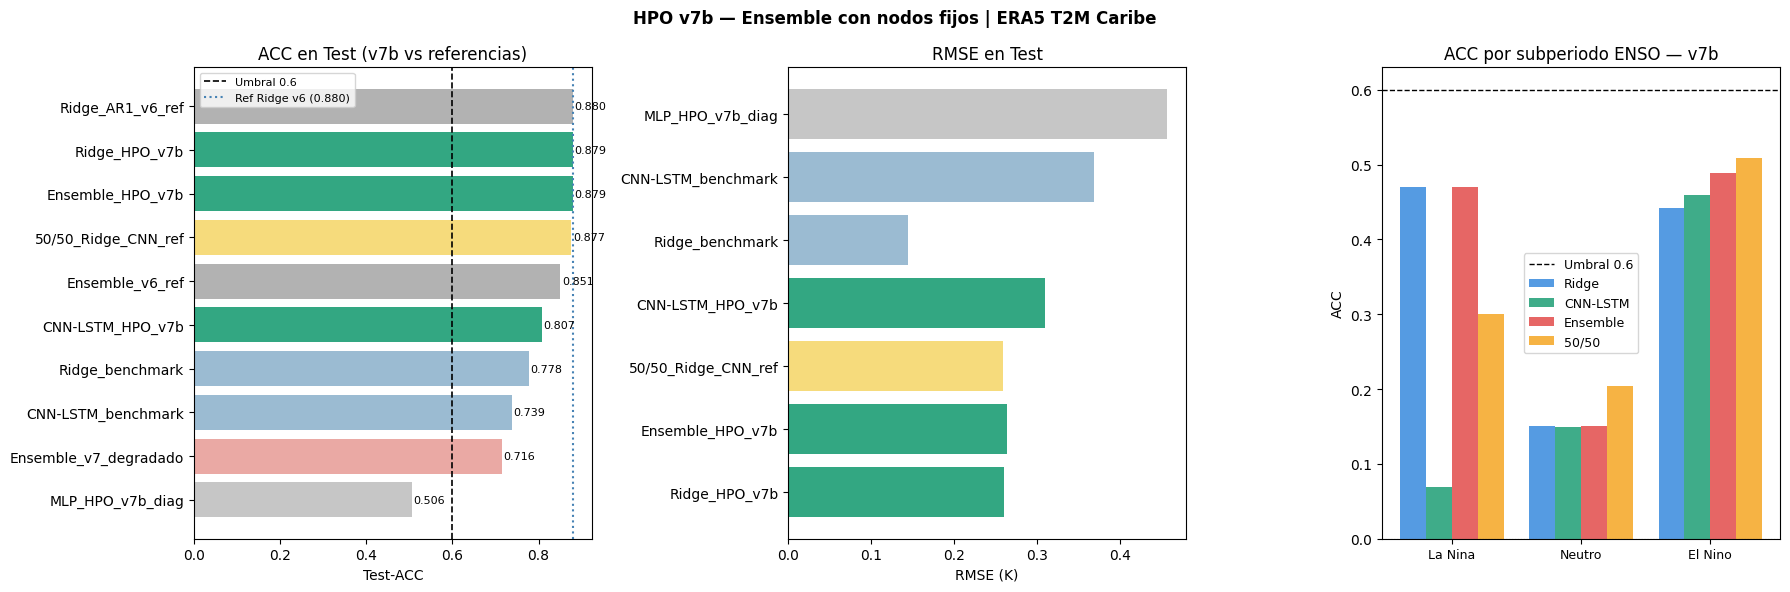

In [13]:
rows = []
bench_modelos = {"Ridge": "Ridge", "CNN-LSTM": "CNN-LSTM"}
for bench_name in bench_modelos:
    row_b = df_bench[df_bench["Modelo"]==bench_name]
    if row_b.empty: continue
    row_b = row_b.iloc[0]
    rows.append({
        "Modelo"       : f"{bench_name}_benchmark",
        "Val-ACC"      : round(row_b["Val-ACC"],      4),
        "Test-RMSE (K)": round(row_b["Test-RMSE (K)"],4),
        "Test-ACC"     : round(row_b["Test-ACC"],     4),
        "Brecha"       : round(row_b["Test-ACC"] - row_b["Val-ACC"], 4),
        "DW"           : "—",
        "Tipo"         : "Benchmark",
    })

# Referencia historica v6
for nombre, acc_ref in [("Ensemble_v6_ref", 0.851), ("Ridge_AR1_v6_ref", 0.880)]:
    rows.append({
        "Modelo": nombre, "Val-ACC": "—", "Test-RMSE (K)": "—",
        "Test-ACC": acc_ref, "Brecha": "—", "DW": "—", "Tipo": "Ref_v6"
    })

# Referencia v7 degradada
rows.append({
    "Modelo": "Ensemble_v7_degradado", "Val-ACC": "—", "Test-RMSE (K)": "—",
    "Test-ACC": 0.716, "Brecha": "—", "DW": "—", "Tipo": "Ref_v7"
})

for name, s in hpo_results.items():
    if "test" not in s: continue
    label = f"{name}_HPO_v7b"
    if name == "MLP": label += "_diag"
    rows.append({
        "Modelo"       : label,
        "Val-ACC"      : round(s["val"]["acc"],  4),
        "Test-RMSE (K)": round(s["test"]["rmse"],4),
        "Test-ACC"     : round(s["test"]["acc"], 4),
        "Brecha"       : round(s["test"]["acc"] - s["val"]["acc"], 4),
        "DW"           : round(s["test"].get("dw", float("nan")), 3),
        "Tipo"         : "Diagnostico" if name == "MLP" else "HPO_v7b",
    })

# 50/50
if "50/50" in test_results:
    rows.append({
        "Modelo": "50/50_Ridge_CNN_ref", "Val-ACC": "—",
        "Test-RMSE (K)": round(test_results["50/50"]["rmse"],4),
        "Test-ACC": round(test_results["50/50"]["acc"],4),
        "Brecha": "—", "DW": round(test_results["50/50"]["dw"],3), "Tipo": "Variante"
    })

df_comp = pd.DataFrame(rows).sort_values(
    "Test-ACC", ascending=False, key=lambda x: pd.to_numeric(x, errors='coerce')
).reset_index(drop=True)
df_comp.to_csv(RESULTS_DIR/"hpo_vs_benchmark.csv", index=False)

print("="*80)
print("  COMPARATIVA HPO v7b vs BENCHMARK")
print("="*80)
print(df_comp.to_string(index=False))

# Figura
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colores = {
    "Benchmark"  : "#90b4ce",
    "HPO_v7b"    : "#1D9E75",
    "Ref_v6"     : "#aaaaaa",
    "Ref_v7"     : "#e8a09a",
    "Variante"   : "#f5d76e",
    "Diagnostico": "#c0c0c0",
}

df_plot = df_comp[df_comp["Test-ACC"] != "—"].copy()
df_plot["Test-ACC_num"] = pd.to_numeric(df_plot["Test-ACC"], errors="coerce")
df_plot = df_plot.dropna(subset=["Test-ACC_num"]).sort_values("Test-ACC_num", ascending=True)

for _, row in df_plot.iterrows():
    c = colores.get(row["Tipo"], "#999")
    axes[0].barh(row["Modelo"], row["Test-ACC_num"], color=c, alpha=0.9)

axes[0].axvline(0.6,  color="black", ls="--", lw=1.2, label="Umbral 0.6")
axes[0].axvline(0.88, color="steelblue", ls=":", lw=1.5, label="Ref Ridge v6 (0.880)")
axes[0].set_xlabel("Test-ACC")
axes[0].set_title("ACC en Test (v7b vs referencias)")
axes[0].legend(fontsize=8)
for i, (_, row) in enumerate(df_plot.iterrows()):
    bar = axes[0].patches[i]
    axes[0].text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                 f"{row['Test-ACC_num']:.3f}", va="center", fontsize=8)

# RMSE
df_rmse = df_comp[pd.to_numeric(df_comp["Test-RMSE (K)"], errors="coerce").notna()].copy()
df_rmse["rmse_num"] = pd.to_numeric(df_rmse["Test-RMSE (K)"], errors="coerce")
for _, row in df_rmse.iterrows():
    c = colores.get(row["Tipo"], "#999")
    axes[1].barh(row["Modelo"], row["rmse_num"], color=c, alpha=0.9)
axes[1].set_xlabel("RMSE (K)"); axes[1].set_title("RMSE en Test")

# Subperiodos
sub_data = {n: test_results[n].get("subperiodos", {})
            for n in ["Ridge","CNN-LSTM","Ensemble","50/50"]
            if n in test_results}
x = np.arange(3); width = 0.2
periodos = ["La Nina (2020-2022)", "Neutro (2022-2023)", "El Nino (2023-2024)"]
colors_sub = {"Ridge":"#378ADD","CNN-LSTM":"#1D9E75","Ensemble":"#E24B4A","50/50":"#F5A623"}

for j, (name, sub) in enumerate(sub_data.items()):
    vals = [sub.get(p, 0) or 0 for p in periodos]
    axes[2].bar(x + j*width, vals, width, label=name,
                color=colors_sub.get(name,"#999"), alpha=0.85)

axes[2].axhline(0.6, color="black", ls="--", lw=1, label="Umbral 0.6")
axes[2].axhline(0,   color="gray",  ls=":",  lw=0.8)
axes[2].set_xticks(x + width*1.5)
axes[2].set_xticklabels(["La Nina","Neutro","El Nino"], fontsize=9)
axes[2].set_ylabel("ACC"); axes[2].set_title("ACC por subperiodo ENSO — v7b")
axes[2].legend(fontsize=9)

fig.suptitle("HPO v7b — Ensemble con nodos fijos | ERA5 T2M Caribe",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR/"figures"/"hpo_vs_benchmark_v7b.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. [M6] Función de inferencia en producción v7b

### Nodos fijos del ensemble

| Regimen | Nodo activo | resid_prev necesario |
|---|---|---|
| La Nina | Ridge+AR(1) | resid_prev_ridge |
| El Nino | CNN-LSTM+AR(1) | resid_prev_cnn (si USE_AR1_CNN=True) |
| Neutro | Ridge+AR(1) fallback | resid_prev_ridge |

### Política de resid_prev

| Situacion | Valor recomendado |
|---|---|
| Primera inferencia | resid_prev = 0 (conservador, AR1=0) |
| Mes anterior observado | resid_prev = y_real(t-1) - y_modelo(t-1) |
| Mes anterior predicho | resid_prev = y_disponible(t-1) - y_modelo(t-1) |

### Assert de rango RONI
Si roni_lag1 sale de [-4.0, 4.0] se lanza ValueError — deteccion de cambio de formato NOAA.

In [14]:
def predict_v7b(X_feat_tab, X_feat_seq, roni_lag1_value, artefactos_dir,
               resid_prev_ridge=None, resid_prev_cnn=None,
               roni_range=(-4.0, 4.0)):
    # [M6] Assert de rango RONI
    roni_lo, roni_hi = roni_range
    if not (roni_lo <= roni_lag1_value <= roni_hi):
        raise ValueError(
            f"[ALERTA] roni_lag1={roni_lag1_value:.3f} fuera del rango "
            f"[{roni_lo}, {roni_hi}]. Verificar fuente RONI (NOAA)."
        )

    artefactos_dir = Path(artefactos_dir)
    with open(artefactos_dir/"ridge_hpo.pkl", "rb") as f: art_ridge  = pickle.load(f)
    with open(artefactos_dir/"cnn_ar1.pkl",   "rb") as f: art_cnn_ar = pickle.load(f)
    cnn_model = keras.models.load_model(artefactos_dir/"cnn_lstm_hpo.keras")

    with open(RESULTS_DIR/"hpo_metadata.json") as f:
        meta = json.load(f)

    thr_nina = meta["ensemble_config"]["thr_nina"]
    thr_nino = meta["ensemble_config"]["thr_nino"]

    # Clasificar regimen
    if roni_lag1_value < thr_nina:
        regime = "La Nina"
    elif roni_lag1_value > thr_nino:
        regime = "El Nino"
    else:
        regime = "Neutro"

    # [M6] Politica resid_prev: None -> 0 (primer mes)
    resid_r = resid_prev_ridge if resid_prev_ridge is not None else 0.0
    resid_c = resid_prev_cnn   if resid_prev_cnn   is not None else 0.0
    if resid_prev_ridge is None:
        print("  INFO: resid_prev_ridge=None -> AR1=0 (primera inferencia)")

    # Ridge+AR(1)
    yp_ridge_sc  = art_ridge["ridge"].predict(X_feat_tab)
    yp_ridge_K   = scaler_y.inverse_transform(yp_ridge_sc.reshape(-1,1)).ravel()[0]
    yp_ridge_ar1 = yp_ridge_K + art_ridge["ar1"].predict([[resid_r]])[0]

    # CNN-LSTM(+AR1) — solo si regimen es El Nino
    yp_cnn_K = None
    if regime == "El Nino":
        t2m_idx  = FEATURE_COLS.index("t2m_lag0") if "t2m_lag0" in FEATURE_COLS else 0
        y_base_t = float(X_feat_tab[0, t2m_idx])
        yp_diff  = cnn_model.predict(X_feat_seq, verbose=0).flatten()[0]
        yp_diff_K = scaler_y_diff.inverse_transform([[yp_diff]])[0][0]
        yp_cnn_K  = y_base_t + yp_diff_K
        if art_cnn_ar["use_ar1"]:
            if resid_prev_cnn is None:
                print("  INFO: resid_prev_cnn=None -> AR1_cnn=0 (primera inferencia)")
            yp_cnn_K += art_cnn_ar["ar1"].predict([[resid_c]])[0]

    # Seleccion por regimen (nodos fijos v7b)
    if regime == "La Nina":
        y_final    = yp_ridge_ar1
        nodo_usado = "Ridge+AR(1)"
    elif regime == "El Nino":
        y_final    = yp_cnn_K
        nodo_usado = "CNN-LSTM+AR(1)" if art_cnn_ar["use_ar1"] else "CNN-LSTM"
    else:  # Neutro
        y_final    = yp_ridge_ar1   # fallback conservador
        nodo_usado = "Ridge+AR(1) [Neutro fallback]"

    return {
        "prediccion_K"   : float(y_final),
        "regime"         : regime,
        "roni_lag1"      : roni_lag1_value,
        "nodo_activo"    : nodo_usado,
        "ridge_ar1_K"    : float(yp_ridge_ar1),
        "cnn_K"          : float(yp_cnn_K) if yp_cnn_K is not None else None,
        "resid_prev_usado": {"ridge": resid_r, "cnn": resid_c},
        "politica_resid" : "cero (primer mes)" if resid_prev_ridge is None else "historico",
    }

print("predict_v7b() definida OK")
print()
print("Uso tipico:")
print("  # Primera inferencia (sin historial):")
print("  res = predict_v7b(X_tab, X_seq, roni_val, RESULTS_DIR/'models')")
print("  # Mes siguiente (con residuo previo):")
print("  resid_r = y_real - res['ridge_ar1_K']")
print("  res = predict_v7b(X_tab, X_seq, roni_val, RESULTS_DIR/'models',")
print("                    resid_prev_ridge=resid_r)")

predict_v7b() definida OK

Uso tipico:
  # Primera inferencia (sin historial):
  res = predict_v7b(X_tab, X_seq, roni_val, RESULTS_DIR/'models')
  # Mes siguiente (con residuo previo):
  resid_r = y_real - res['ridge_ar1_K']
  res = predict_v7b(X_tab, X_seq, roni_val, RESULTS_DIR/'models',
                    resid_prev_ridge=resid_r)


## 11. Exportación de metadatos

In [15]:
meta_hpo = {
    "version"              : "v7b",
    "n_features"           : N_FEATURES,
    "roni_integrado"       : True,
    "diagnostico_v7"       : {
        "problema": "Ensemble v7 degradado (0.716) por MLP y Ridge_neutro",
        "causa"   : "Sesgo MLP en test distinto al calibrado en val; n_Neutro_train~14 insuficiente",
        "correccion": "Nodos ensemble fijos — eliminada seleccion dinamica por val",
    },
    "mejoras_activas_v7b"  : [
        "[M1] AR(1) sobre residuos CNN-LSTM (criterio DW>1.20, |Bias|<0.10K, ΔACC>=-0.02)",
        "[M4] Tracking de sesgo en todos los modelos",
        "[M5] DM test + bootstrap estratificado por regimen ENSO",
        "[M6] predict() con politica explicita de resid_prev + assert rango RONI",
    ],
    "mejoras_desactivadas" : [
        "[M2] MLP en ensemble — diagnostico solo, sesgo no generaliza",
        "[M3] Ridge_neutro en ensemble — n_Neutro_train insuficiente",
    ],
    "ensemble_config"      : {
        "thr_nina"   : hpo_results["Ensemble"]["best_config"]["thr_nina"],
        "thr_nino"   : hpo_results["Ensemble"]["best_config"]["thr_nino"],
        "nodo_nina"  : "Ridge+AR(1)",
        "nodo_nino"  : "CNN-LSTM+AR(1)" if USE_AR1_CNN else "CNN-LSTM",
        "nodo_neutro": "Ridge+AR(1) fallback",
    },
    "test_results"         : {
        name: {k: round(v,4) if isinstance(v,float) else v
               for k,v in s.get("test",{}).items()}
        for name, s in hpo_results.items() if "test" in s
    },
    "use_ar1_cnn"   : bool(USE_AR1_CNN),
    "phi_ridge_ar1" : float(phi_ridge),
    "phi_cnn_ar1"   : float(phi_cnn) if USE_AR1_CNN else None,
}

with open(RESULTS_DIR/"hpo_metadata.json", "w") as f:
    json.dump(meta_hpo, f, indent=2, default=str)

print("Artefactos en results_v7b/:")
for fp in sorted(RESULTS_DIR.rglob("*")):
    if fp.is_file():
        print(f"  {str(fp.relative_to(RESULTS_DIR)):<50} {fp.stat().st_size/1024:.1f} KB")

print("\nHPO v7b completado")
print(f"  Ridge+AR(1):    {test_results['Ridge']['acc']:.4f}  (ref v6: 0.880)")
print(f"  CNN-LSTM+AR(1): {test_results['CNN-LSTM']['acc']:.4f}  (bench: 0.748)")
print(f"  Ensemble v7b:   {test_results['Ensemble']['acc']:.4f}  (v7: 0.716, v6: 0.851)")
print(f"  50/50 ref:      {test_results.get('50/50',{}).get('acc','—')}")
print(f"  Nodos: La Nina=Ridge+AR1 | El Nino=CNN+AR1 | Neutro=Ridge+AR1(fallback)")

Artefactos en results_v7b/:
  figures\cnn_lstm_optuna.png                        112.0 KB
  figures\hpo_vs_benchmark_v7b.png                   161.3 KB
  hpo_metadata.json                                  2.3 KB
  hpo_vs_benchmark.csv                               0.6 KB
  logs\bootstrap_acc_by_regime.csv                   0.4 KB
  logs\cnn_lstm_trials.csv                           13.8 KB
  models\cnn_ar1.pkl                                 0.5 KB
  models\cnn_lstm_hpo.keras                          378.6 KB
  models\mlp_hpo.pkl                                 136.6 KB
  models\ridge_hpo.pkl                               1.0 KB
  models\ridge_hpo_meta.json                         0.2 KB
  models\ridge_neutro.pkl                            0.7 KB
  study.db                                           312.0 KB

HPO v7b completado
  Ridge+AR(1):    0.8795  (ref v6: 0.880)
  CNN-LSTM+AR(1): 0.8074  (bench: 0.748)
  Ensemble v7b:   0.8790  (v7: 0.716, v6: 0.851)
  50/50 ref:      0.876598510